In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('heart.csv')
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
# Kiểm tra số lượng dòng trùng lặp
print("Số dòng trùng lặp:", df.duplicated().sum())

# Xóa trùng lặp để mô hình khách quan hơn:
df = df.drop_duplicates()
print("Số dòng trùng lặp:", df.duplicated().sum())

Số dòng trùng lặp: 723
Số dòng trùng lặp: 0


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


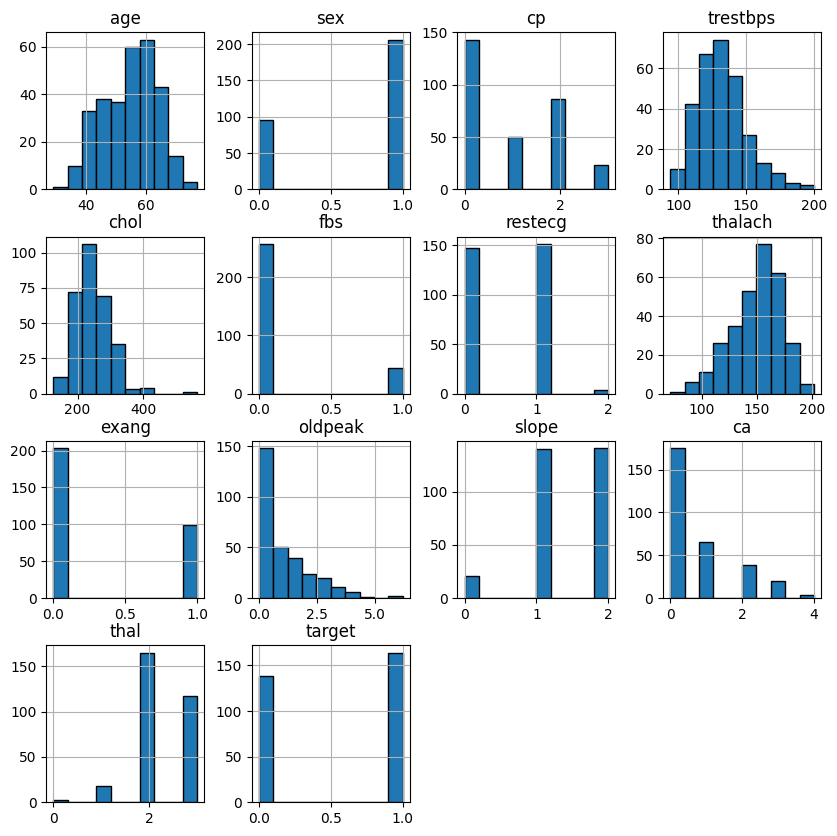

In [ ]:
df.hist(figsize=(10,10),edgecolor='black')
plt.show()

In [ ]:
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [ ]:
X = df.drop('target',axis=1)
y = df.target

In [ ]:
print(X.shape)
print(y.shape)

(302, 13)
(302,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(241, 13)
(61, 13)
(241,)
(61,)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train_df = pd.DataFrame(X_train, columns=X.columns)

# Hiển thị 5 dòng đầu tiên của bảng
X_train_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.682633,0.685210,-0.980054,-0.403153,0.486281,-0.425879,-1.024877,0.717007,-0.718139,-0.447524,-0.715539,-0.705536,1.118119
1,0.403989,0.685210,-0.980054,-0.171406,0.206315,-0.425879,-1.024877,-0.836627,1.392489,1.768032,-0.715539,1.248879,1.118119
2,-1.008619,-1.459407,-0.004050,-0.055533,-0.260295,-0.425879,-1.024877,1.105415,-0.718139,-0.358902,-0.715539,-0.705536,-0.545256
3,-1.117282,0.685210,-0.004050,-0.634899,-0.521596,-0.425879,0.860584,0.889633,-0.718139,-0.890635,0.991836,-0.705536,-0.545256
4,0.838637,-1.459407,-0.980054,1.103201,-0.073651,-0.425879,0.860584,0.199129,1.392489,0.350076,-0.715539,-0.705536,-0.545256


Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lg_model = LogisticRegression()
lg_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_lg_pred = lg_model.predict(X_test)
cmlg = confusion_matrix(y_test, y_lg_pred)
print(cmlg)
acclg = accuracy_score(y_test, y_lg_pred)
print(acclg)

[[21 11]
 [ 3 26]]
0.7704918032786885


KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_knn_pred = knn_model.predict(X_test)
knn_cm = confusion_matrix(y_test, y_knn_pred)
print(knn_cm)
knn_ac = accuracy_score(y_test, y_knn_pred)
print(knn_ac)

[[22 10]
 [ 6 23]]
0.7377049180327869


SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score
svm_model = SVC()
svm_model.fit(X_train, y_train)
y_svm_pred = svm_model.predict(X_test)
svm_cm = confusion_matrix(y_test, y_svm_pred)
print(svm_cm)
svm_ac = accuracy_score(y_test, y_svm_pred)
print(svm_ac)

[[24  8]
 [ 5 24]]
0.7868852459016393


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_dt_pred = dt_model.predict(X_test)
dt_cm = confusion_matrix(y_test, y_dt_pred)
print(dt_cm)
dt_ac = accuracy_score(y_test, y_dt_pred)
print(dt_ac)

[[25  7]
 [10 19]]
0.7213114754098361


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_rf_pred = rf_model.predict(X_test)
rf_cm = confusion_matrix(y_test, y_rf_pred)
print(rf_cm)
rf_ac = accuracy_score(y_test, y_rf_pred)
print(rf_ac)

[[25  7]
 [ 3 26]]
0.8360655737704918


In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({'Thực tế (Actual)': y_test.values, 'Dự đoán (Predicted)': y_rf_pred})
comparison_df.head(20) # Xem trước 20 dòng đầu tiên

,Thực tế (Actual),Dự đoán (Predicted)
0,1,1
1,0,1
2,0,0
3,1,0
4,1,1
5,0,0
6,0,0
7,1,1
8,1,1
9,0,1
